# 03 - Analysis

This notebook performs Phase 4 analysis only: normalized performance visuals, correlation heatmaps, oil sensitivity regressions, oil sensitivity ranking, and oil shock analysis.

It does not create Tableau validation outputs or begin Phase 5.

## Imports and path setup

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
IMAGES_DIR = PROJECT_ROOT / 'images'
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

WEEKLY_RETURNS_PATH = PROCESSED_DIR / 'weekly_returns.csv'
MONTHLY_RETURNS_PATH = PROCESSED_DIR / 'monthly_returns.csv'
WEEKLY_EXCESS_PATH = PROCESSED_DIR / 'weekly_excess_returns.csv'
MONTHLY_EXCESS_PATH = PROCESSED_DIR / 'monthly_excess_returns.csv'

OIL_SENSITIVITY_PATH = PROCESSED_DIR / 'oil_sensitivity_summary.csv'
OIL_SHOCK_PATH = PROCESSED_DIR / 'oil_shock_summary.csv'

NORMALIZED_PERFORMANCE_PATH = IMAGES_DIR / 'normalized_performance.png'
WEEKLY_CORR_PATH = IMAGES_DIR / 'weekly_correlation_heatmap.png'
MONTHLY_CORR_PATH = IMAGES_DIR / 'monthly_correlation_heatmap.png'
OIL_SENSITIVITY_RANKING_PATH = IMAGES_DIR / 'oil_sensitivity_ranking.png'

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 130

print(f'Project root: {PROJECT_ROOT}')

Project root: /home/marcusai/MyProjects/Oil vs Airline Stocks Data Analysis


## Load configuration and Phase 3 outputs

In [2]:
from config import AIRLINE_CLASSIFICATION, TICKERS

expected_assets = list(TICKERS.keys())
airlines = list(AIRLINE_CLASSIFICATION.keys())
oil_asset = 'Brent Oil'
market_asset = 'S&P 500'

weekly_returns = pd.read_csv(WEEKLY_RETURNS_PATH, parse_dates=['Date'], index_col='Date').sort_index()
monthly_returns = pd.read_csv(MONTHLY_RETURNS_PATH, parse_dates=['Date'], index_col='Date').sort_index()
weekly_excess_returns = pd.read_csv(WEEKLY_EXCESS_PATH, parse_dates=['Date'], index_col='Date').sort_index()
monthly_excess_returns = pd.read_csv(MONTHLY_EXCESS_PATH, parse_dates=['Date'], index_col='Date').sort_index()

for name, df in {
    'weekly_returns': weekly_returns,
    'monthly_returns': monthly_returns,
    'weekly_excess_returns': weekly_excess_returns,
    'monthly_excess_returns': monthly_excess_returns,
}.items():
    if df.empty:
        raise ValueError(f'{name} is empty')

if list(weekly_returns.columns) != expected_assets:
    raise ValueError('weekly_returns columns do not match expected assets')
if list(monthly_returns.columns) != expected_assets:
    raise ValueError('monthly_returns columns do not match expected assets')
if list(weekly_excess_returns.columns) != airlines:
    raise ValueError('weekly_excess_returns columns do not match airlines')
if list(monthly_excess_returns.columns) != airlines:
    raise ValueError('monthly_excess_returns columns do not match airlines')

print('Weekly returns shape:', weekly_returns.shape)
print('Monthly returns shape:', monthly_returns.shape)
print('Weekly excess returns shape:', weekly_excess_returns.shape)
print('Monthly excess returns shape:', monthly_excess_returns.shape)

Weekly returns shape: (440, 6)
Monthly returns shape: (101, 6)
Weekly excess returns shape: (440, 4)
Monthly excess returns shape: (101, 4)


## Missing-value check

Missing values are checked before analysis. The Phase 3 outputs should be clean, but this notebook still reports them explicitly.

In [3]:
missing_value_summary = {
    'weekly_returns': weekly_returns.isna().sum().astype(int).to_dict(),
    'monthly_returns': monthly_returns.isna().sum().astype(int).to_dict(),
    'weekly_excess_returns': weekly_excess_returns.isna().sum().astype(int).to_dict(),
    'monthly_excess_returns': monthly_excess_returns.isna().sum().astype(int).to_dict(),
}

for dataset_name, summary in missing_value_summary.items():
    print(dataset_name)
    print(summary)
    print()

if any(any(count > 0 for count in summary.values()) for summary in missing_value_summary.values()):
    print('Missing values detected in input returns; regression functions will drop missing observations pairwise.')
else:
    print('No missing values detected in input return datasets.')

weekly_returns
{'Brent Oil': 0, 'Ryanair': 0, 'Lufthansa': 0, 'Southwest': 0, 'American Airlines': 0, 'S&P 500': 0}

monthly_returns
{'Brent Oil': 0, 'Ryanair': 0, 'Lufthansa': 0, 'Southwest': 0, 'American Airlines': 0, 'S&P 500': 0}

weekly_excess_returns
{'Ryanair': 0, 'Lufthansa': 0, 'Southwest': 0, 'American Airlines': 0}

monthly_excess_returns
{'Ryanair': 0, 'Lufthansa': 0, 'Southwest': 0, 'American Airlines': 0}

No missing values detected in input return datasets.


## Normalized performance visual

Normalized performance is built from monthly returns and starts at 100. Monthly data is the primary interpretation layer from the project plan.

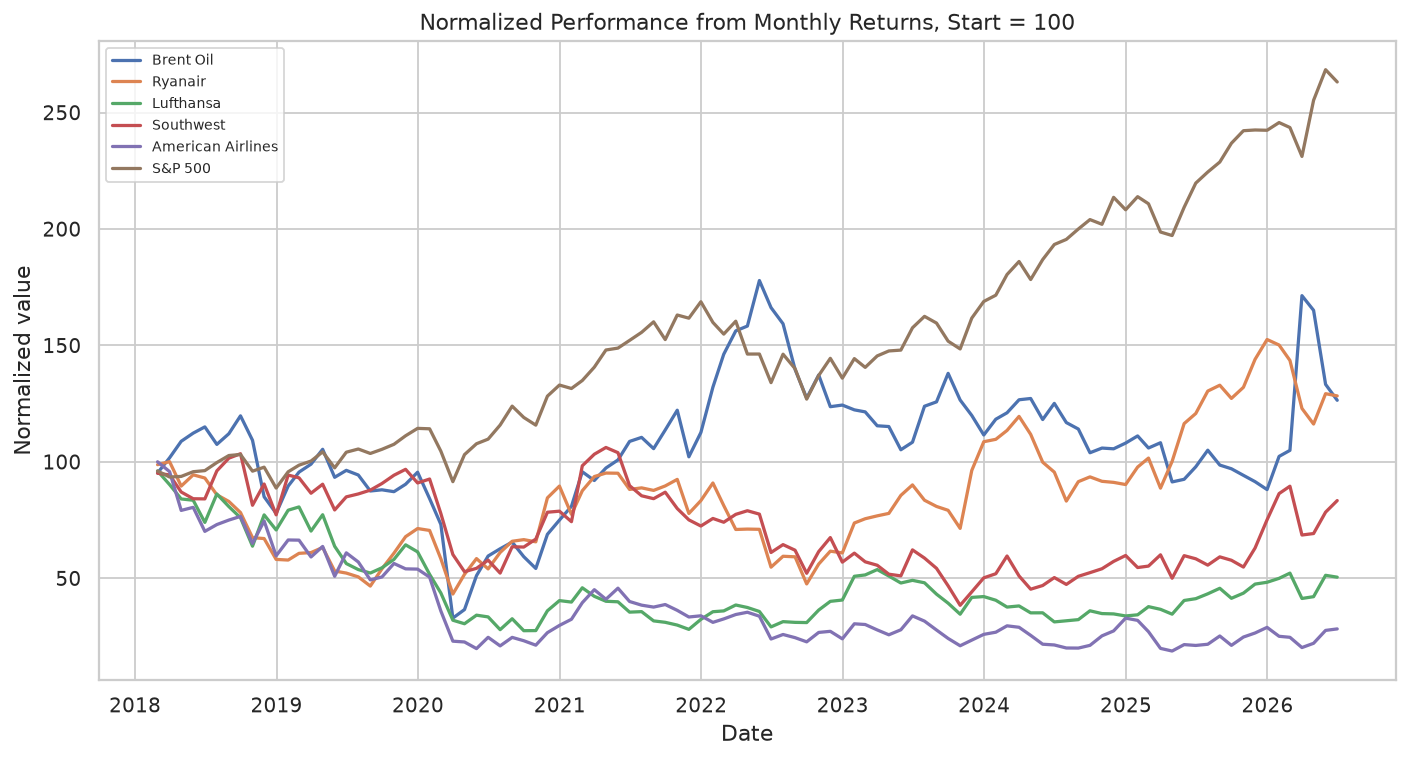

Saved: /home/marcusai/MyProjects/Oil vs Airline Stocks Data Analysis/images/normalized_performance.png


In [4]:
normalized_performance = (1 + monthly_returns).cumprod() * 100

fig, ax = plt.subplots(figsize=(11, 6))
for column in normalized_performance.columns:
    ax.plot(normalized_performance.index, normalized_performance[column], label=column, linewidth=1.8)

ax.set_title('Normalized Performance from Monthly Returns, Start = 100')
ax.set_xlabel('Date')
ax.set_ylabel('Normalized value')
ax.legend(loc='best', fontsize=8)
fig.tight_layout()
fig.savefig(NORMALIZED_PERFORMANCE_PATH, bbox_inches='tight')
plt.show()

print(f'Saved: {NORMALIZED_PERFORMANCE_PATH}')

## Weekly and monthly correlation heatmaps

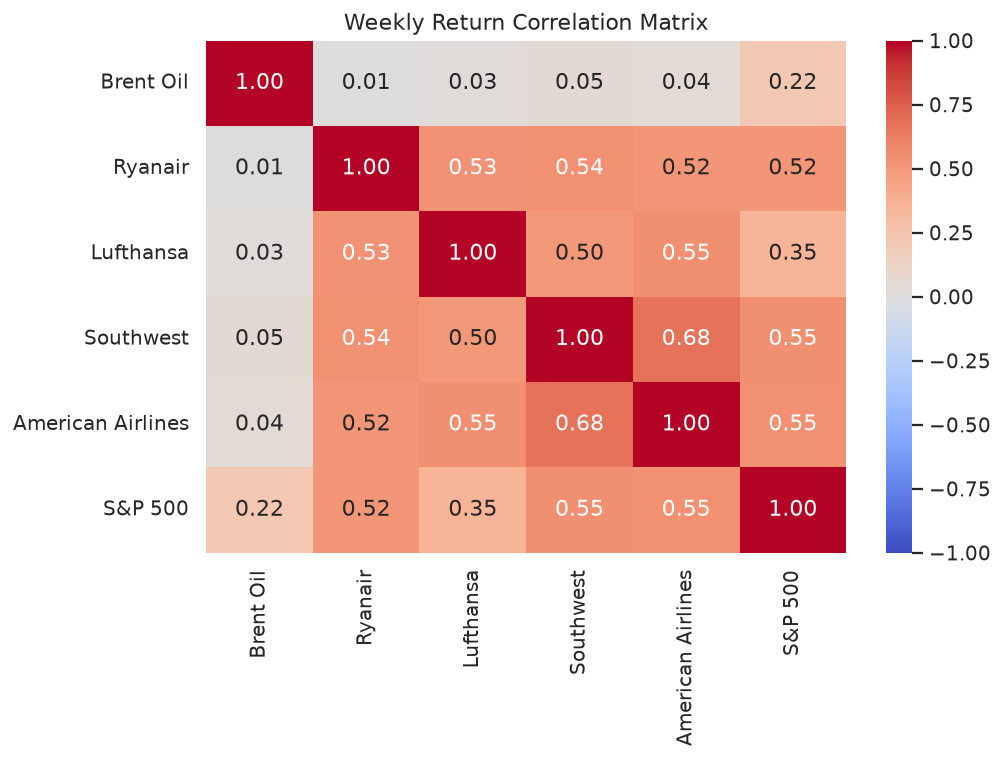

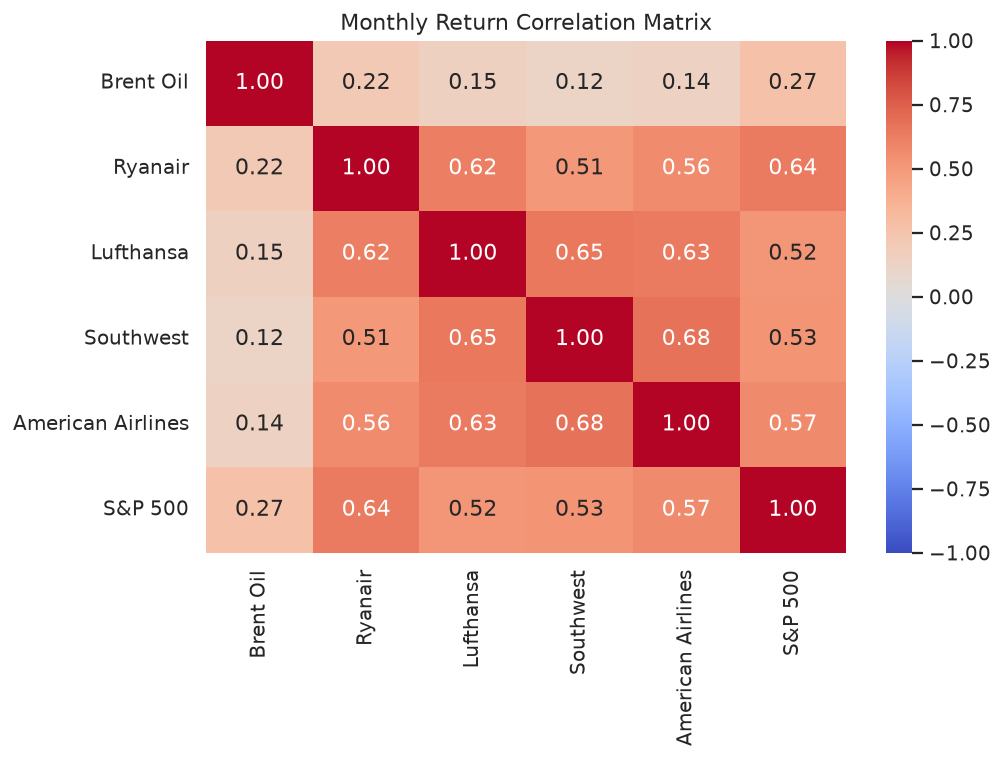

Saved: /home/marcusai/MyProjects/Oil vs Airline Stocks Data Analysis/images/weekly_correlation_heatmap.png
Saved: /home/marcusai/MyProjects/Oil vs Airline Stocks Data Analysis/images/monthly_correlation_heatmap.png


In [5]:
weekly_corr = weekly_returns.corr()
monthly_corr = monthly_returns.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(weekly_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Weekly Return Correlation Matrix')
fig.tight_layout()
fig.savefig(WEEKLY_CORR_PATH, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(monthly_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Monthly Return Correlation Matrix')
fig.tight_layout()
fig.savefig(MONTHLY_CORR_PATH, bbox_inches='tight')
plt.show()

print(f'Saved: {WEEKLY_CORR_PATH}')
print(f'Saved: {MONTHLY_CORR_PATH}')

## Oil sensitivity regression

For each airline, estimate:

`airline_return = alpha + beta × brent_return`

This is done for weekly returns, monthly returns, weekly excess returns, and monthly excess returns.

In [6]:
def interpret_beta(airline, beta, return_type):
    direction = 'increase' if beta >= 0 else 'decrease'
    return (
        f'A 1% increase in Brent returns was associated with a '
        f'{abs(beta):.2f}% {direction} in {airline} {return_type.lower()}.'
    )


def run_oil_sensitivity(return_df, frequency, return_type, y_columns):
    rows = []
    for airline in y_columns:
        analysis_df = pd.concat([
            return_df[[oil_asset]].rename(columns={oil_asset: 'brent_return'}),
            return_df[[airline]].rename(columns={airline: 'airline_return'}),
        ], axis=1).dropna()

        if analysis_df.empty or len(analysis_df) < 3:
            raise ValueError(f'Not enough observations for {frequency} {return_type} {airline}')

        regression = stats.linregress(
            analysis_df['brent_return'].astype(float),
            analysis_df['airline_return'].astype(float),
        )
        beta = regression.slope
        alpha = regression.intercept
        r_squared = regression.rvalue ** 2
        p_value = regression.pvalue

        rows.append({
            'airline': airline,
            'frequency': frequency,
            'return_type': return_type,
            'alpha': alpha,
            'beta': beta,
            'r_squared': r_squared,
            'p_value': p_value,
            'interpretation': interpret_beta(airline, beta, return_type),
            'significant': bool(p_value < 0.05),
            'beta_confidence_score': abs(beta) * r_squared,
            'observations': len(analysis_df),
        })
    return rows

sensitivity_rows = []
sensitivity_rows.extend(run_oil_sensitivity(weekly_returns, 'Weekly', 'Returns', airlines))
sensitivity_rows.extend(run_oil_sensitivity(monthly_returns, 'Monthly', 'Returns', airlines))

weekly_excess_for_regression = weekly_excess_returns.join(weekly_returns[[oil_asset]])
monthly_excess_for_regression = monthly_excess_returns.join(monthly_returns[[oil_asset]])
sensitivity_rows.extend(run_oil_sensitivity(weekly_excess_for_regression, 'Weekly', 'Excess Returns', airlines))
sensitivity_rows.extend(run_oil_sensitivity(monthly_excess_for_regression, 'Monthly', 'Excess Returns', airlines))

oil_sensitivity_summary = pd.DataFrame(sensitivity_rows)

oil_sensitivity_summary['beta_rank'] = (
    oil_sensitivity_summary
    .groupby(['frequency', 'return_type'])['beta']
    .transform(lambda s: s.abs().rank(method='first', ascending=False).astype(int))
)

required_sensitivity_columns = [
    'airline', 'frequency', 'return_type', 'alpha', 'beta', 'r_squared', 'p_value',
    'interpretation', 'beta_rank', 'significant', 'beta_confidence_score'
]
oil_sensitivity_summary = oil_sensitivity_summary[required_sensitivity_columns]
oil_sensitivity_summary = oil_sensitivity_summary.sort_values(['frequency', 'return_type', 'beta_rank']).reset_index(drop=True)

oil_sensitivity_summary.to_csv(OIL_SENSITIVITY_PATH, index=False)
display(oil_sensitivity_summary)
print(f'Saved: {OIL_SENSITIVITY_PATH}')

,airline,frequency,return_type,alpha,beta,r_squared,p_value,interpretation,beta_rank,significant,beta_confidence_score
0,Ryanair,Monthly,Excess Returns,-0.003844,0.075530,0.013538,0.246563,A 1% increase in Brent returns was associated ...,1,False,1.022566e-03
1,American Airlines,Monthly,Excess Returns,-0.015054,0.047403,0.002930,0.590809,A 1% increase in Brent returns was associated ...,2,False,1.389140e-04
2,Lufthansa,Monthly,Excess Returns,-0.012311,0.024105,0.001122,0.739469,A 1% increase in Brent returns was associated ...,3,False,2.704915e-05
3,Southwest,Monthly,Excess Returns,-0.006807,0.001840,0.000006,0.980123,A 1% increase in Brent returns was associated ...,4,False,1.159318e-08
4,Ryanair,Monthly,Returns,0.005867,0.176739,0.046314,0.030674,A 1% increase in Brent returns was associated ...,1,True,8.185497e-03
5,American Airlines,Monthly,Returns,-0.005343,0.148612,0.020558,0.152593,A 1% increase in Brent returns was associated ...,2,False,3.055190e-03
6,Lufthansa,Monthly,Returns,-0.002601,0.125314,0.022279,0.136291,A 1% increase in Brent returns was associated ...,3,False,2.791868e-03
7,Southwest,Monthly,Returns,0.002904,0.103049,0.014357,0.232678,A 1% increase in Brent returns was associated ...,4,False,1.479443e-03
8,Ryanair,Weekly,Excess Returns,-0.000138,-0.085014,0.011570,0.024045,A 1% increase in Brent returns was associated ...,1,True,9.836188e-04
9,Lufthansa,Weekly,Excess Returns,-0.002580,-0.070330,0.006082,0.102310,A 1% increase in Brent returns was associated ...,2,False,4.277745e-04


Saved: /home/marcusai/MyProjects/Oil vs Airline Stocks Data Analysis/data/processed/oil_sensitivity_summary.csv


## Oil sensitivity ranking visual

The ranking visual uses absolute beta magnitude. It shows all four required categories.

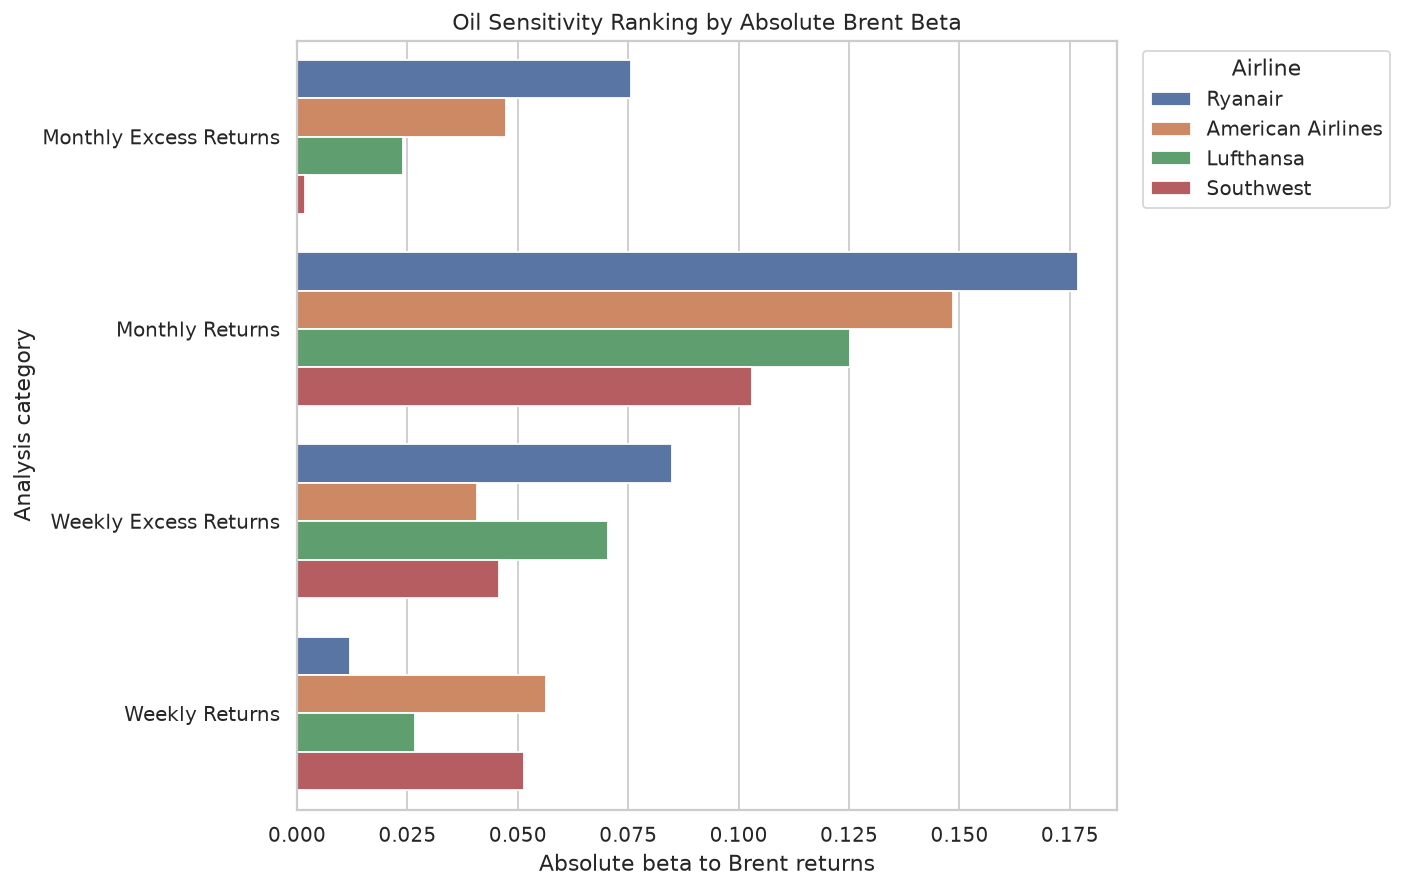

Saved: /home/marcusai/MyProjects/Oil vs Airline Stocks Data Analysis/images/oil_sensitivity_ranking.png


In [7]:
plot_df = oil_sensitivity_summary.copy()
plot_df['category'] = plot_df['frequency'] + ' ' + plot_df['return_type']
plot_df['absolute_beta'] = plot_df['beta'].abs()

fig, ax = plt.subplots(figsize=(11, 7))
sns.barplot(
    data=plot_df,
    y='category',
    x='absolute_beta',
    hue='airline',
    ax=ax,
)
ax.set_title('Oil Sensitivity Ranking by Absolute Brent Beta')
ax.set_xlabel('Absolute beta to Brent returns')
ax.set_ylabel('Analysis category')
ax.legend(title='Airline', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
fig.savefig(OIL_SENSITIVITY_RANKING_PATH, bbox_inches='tight')
plt.show()

print(f'Saved: {OIL_SENSITIVITY_RANKING_PATH}')

## Oil shock analysis

Oil shock periods are defined separately for weekly and monthly returns as the top 20% of positive Brent return periods. For each airline, calculate average airline return and average excess return during those shock periods.

In [8]:
def build_oil_shock_summary(return_df, excess_df, frequency):
    positive_brent = return_df.loc[return_df[oil_asset] > 0, oil_asset]
    if positive_brent.empty:
        raise ValueError(f'No positive Brent return periods found for {frequency}')
    shock_threshold = positive_brent.quantile(0.80)
    shock_dates = return_df.index[return_df[oil_asset] >= shock_threshold]

    rows = []
    for airline in airlines:
        rows.append({
            'airline': airline,
            'frequency': frequency,
            'oil_shock_count': int(len(shock_dates)),
            'average_return_during_oil_shocks': return_df.loc[shock_dates, airline].mean(),
            'average_excess_return_during_oil_shocks': excess_df.loc[shock_dates, airline].mean(),
        })
    return pd.DataFrame(rows)

weekly_oil_shock = build_oil_shock_summary(weekly_returns, weekly_excess_returns, 'Weekly')
monthly_oil_shock = build_oil_shock_summary(monthly_returns, monthly_excess_returns, 'Monthly')

oil_shock_summary = pd.concat([weekly_oil_shock, monthly_oil_shock], ignore_index=True)
oil_shock_summary = oil_shock_summary.sort_values(['frequency', 'airline']).reset_index(drop=True)
oil_shock_summary.to_csv(OIL_SHOCK_PATH, index=False)

display(oil_shock_summary)
print(f'Saved: {OIL_SHOCK_PATH}')

,airline,frequency,oil_shock_count,average_return_during_oil_shocks,average_excess_return_during_oil_shocks
0,American Airlines,Monthly,12,0.019159,-0.006909
1,Lufthansa,Monthly,12,0.042068,0.016001
2,Ryanair,Monthly,12,0.034576,0.008508
3,Southwest,Monthly,12,0.045837,0.019769
4,American Airlines,Weekly,48,0.011153,-0.001552
5,Lufthansa,Weekly,48,0.001558,-0.011147
6,Ryanair,Weekly,48,0.006543,-0.006162
7,Southwest,Weekly,48,0.007901,-0.004804


Saved: /home/marcusai/MyProjects/Oil vs Airline Stocks Data Analysis/data/processed/oil_shock_summary.csv


## Summary views for final reporting

In [9]:
top_beta_rankings = (
    oil_sensitivity_summary
    .loc[oil_sensitivity_summary['beta_rank'] == 1]
    .sort_values(['frequency', 'return_type'])
    .reset_index(drop=True)
)

significant_relationships = (
    oil_sensitivity_summary
    .loc[oil_sensitivity_summary['significant']]
    .sort_values(['frequency', 'return_type', 'p_value'])
    .reset_index(drop=True)
)

highest_confidence_scores = (
    oil_sensitivity_summary
    .sort_values('beta_confidence_score', ascending=False)
    .reset_index(drop=True)
)

display(top_beta_rankings)
display(significant_relationships)
display(highest_confidence_scores.head(10))

,airline,frequency,return_type,alpha,beta,r_squared,p_value,interpretation,beta_rank,significant,beta_confidence_score
0,Ryanair,Monthly,Excess Returns,-0.003844,0.075530,0.013538,0.246563,A 1% increase in Brent returns was associated ...,1,False,0.001023
1,Ryanair,Monthly,Returns,0.005867,0.176739,0.046314,0.030674,A 1% increase in Brent returns was associated ...,1,True,0.008185
2,Ryanair,Weekly,Excess Returns,-0.000138,-0.085014,0.011570,0.024045,A 1% increase in Brent returns was associated ...,1,True,0.000984
3,American Airlines,Weekly,Returns,0.000143,0.056332,0.001621,0.399530,A 1% increase in Brent returns was associated ...,1,False,0.000091


,airline,frequency,return_type,alpha,beta,r_squared,p_value,interpretation,beta_rank,significant,beta_confidence_score
0,Ryanair,Monthly,Returns,0.005867,0.176739,0.046314,0.030674,A 1% increase in Brent returns was associated ...,1,True,0.008185
1,Ryanair,Weekly,Excess Returns,-0.000138,-0.085014,0.011570,0.024045,A 1% increase in Brent returns was associated ...,1,True,0.000984


,airline,frequency,return_type,alpha,beta,r_squared,p_value,interpretation,beta_rank,significant,beta_confidence_score
0,Ryanair,Monthly,Returns,0.005867,0.176739,0.046314,0.030674,A 1% increase in Brent returns was associated ...,1,True,0.008185
1,American Airlines,Monthly,Returns,-0.005343,0.148612,0.020558,0.152593,A 1% increase in Brent returns was associated ...,2,False,0.003055
2,Lufthansa,Monthly,Returns,-0.002601,0.125314,0.022279,0.136291,A 1% increase in Brent returns was associated ...,3,False,0.002792
3,Southwest,Monthly,Returns,0.002904,0.103049,0.014357,0.232678,A 1% increase in Brent returns was associated ...,4,False,0.001479
4,Ryanair,Monthly,Excess Returns,-0.003844,0.075530,0.013538,0.246563,A 1% increase in Brent returns was associated ...,1,False,0.001023
5,Ryanair,Weekly,Excess Returns,-0.000138,-0.085014,0.011570,0.024045,A 1% increase in Brent returns was associated ...,1,True,0.000984
6,Lufthansa,Weekly,Excess Returns,-0.002580,-0.070330,0.006082,0.102310,A 1% increase in Brent returns was associated ...,2,False,0.000428
7,Southwest,Weekly,Excess Returns,-0.001521,-0.045704,0.003306,0.228756,A 1% increase in Brent returns was associated ...,3,False,0.000151
8,Southwest,Weekly,Returns,0.000855,0.051321,0.002926,0.257558,A 1% increase in Brent returns was associated ...,2,False,0.000150
9,American Airlines,Monthly,Excess Returns,-0.015054,0.047403,0.002930,0.590809,A 1% increase in Brent returns was associated ...,2,False,0.000139


## Phase 4 validation

In [10]:
visual_paths = [
    NORMALIZED_PERFORMANCE_PATH,
    WEEKLY_CORR_PATH,
    MONTHLY_CORR_PATH,
    OIL_SENSITIVITY_RANKING_PATH,
]
summary_paths = [OIL_SENSITIVITY_PATH, OIL_SHOCK_PATH]

for path in visual_paths + summary_paths:
    assert path.exists(), f'Missing expected output: {path}'
    assert path.stat().st_size > 0, f'Output exists but is empty: {path}'

saved_sensitivity = pd.read_csv(OIL_SENSITIVITY_PATH)
saved_shock = pd.read_csv(OIL_SHOCK_PATH)

assert list(saved_sensitivity.columns) == required_sensitivity_columns, 'Oil sensitivity columns do not match requirements.'
assert list(saved_shock.columns) == [
    'airline', 'frequency', 'oil_shock_count',
    'average_return_during_oil_shocks', 'average_excess_return_during_oil_shocks'
], 'Oil shock columns do not match requirements.'
assert saved_sensitivity.isna().sum().sum() == 0, 'Oil sensitivity summary contains missing values.'
assert saved_shock.isna().sum().sum() == 0, 'Oil shock summary contains missing values.'
assert set(saved_sensitivity['airline']) == set(airlines), 'Regression results missing airlines.'
assert set(saved_sensitivity['frequency']) == {'Weekly', 'Monthly'}, 'Regression results missing frequencies.'
assert set(saved_sensitivity['return_type']) == {'Returns', 'Excess Returns'}, 'Regression results missing return types.'
assert saved_sensitivity.groupby(['frequency', 'return_type'])['airline'].nunique().eq(4).all(), 'Each ranking category must contain all four airlines.'
assert saved_sensitivity['beta_rank'].notna().all(), 'beta_rank has missing values.'
assert saved_sensitivity['significant'].notna().all(), 'significant has missing values.'
assert saved_sensitivity['beta_confidence_score'].notna().all(), 'beta_confidence_score has missing values.'
assert set(saved_shock['airline']) == set(airlines), 'Oil shock summary missing airlines.'
assert set(saved_shock['frequency']) == {'Weekly', 'Monthly'}, 'Oil shock summary missing frequencies.'

validation_summary = {
    'oil_sensitivity_summary_exists': OIL_SENSITIVITY_PATH.exists(),
    'oil_shock_summary_exists': OIL_SHOCK_PATH.exists(),
    'visual_files_exist': {path.name: path.exists() for path in visual_paths},
    'oil_sensitivity_shape': saved_sensitivity.shape,
    'oil_shock_shape': saved_shock.shape,
    'sensitivity_missing_values': saved_sensitivity.isna().sum().astype(int).to_dict(),
    'shock_missing_values': saved_shock.isna().sum().astype(int).to_dict(),
    'frequencies': sorted(saved_sensitivity['frequency'].unique().tolist()),
    'return_types': sorted(saved_sensitivity['return_type'].unique().tolist()),
}

validation_summary

{'oil_sensitivity_summary_exists': True,
 'oil_shock_summary_exists': True,
 'visual_files_exist': {'normalized_performance.png': True,
  'weekly_correlation_heatmap.png': True,
  'monthly_correlation_heatmap.png': True,
  'oil_sensitivity_ranking.png': True},
 'oil_sensitivity_shape': (16, 11),
 'oil_shock_shape': (8, 5),
 'sensitivity_missing_values': {'airline': 0,
  'frequency': 0,
  'return_type': 0,
  'alpha': 0,
  'beta': 0,
  'r_squared': 0,
  'p_value': 0,
  'interpretation': 0,
  'beta_rank': 0,
  'significant': 0,
  'beta_confidence_score': 0},
 'shock_missing_values': {'airline': 0,
  'frequency': 0,
  'oil_shock_count': 0,
  'average_return_during_oil_shocks': 0,
  'average_excess_return_during_oil_shocks': 0},
 'frequencies': ['Monthly', 'Weekly'],
 'return_types': ['Excess Returns', 'Returns']}